**Real-time AI Object Tracker:**

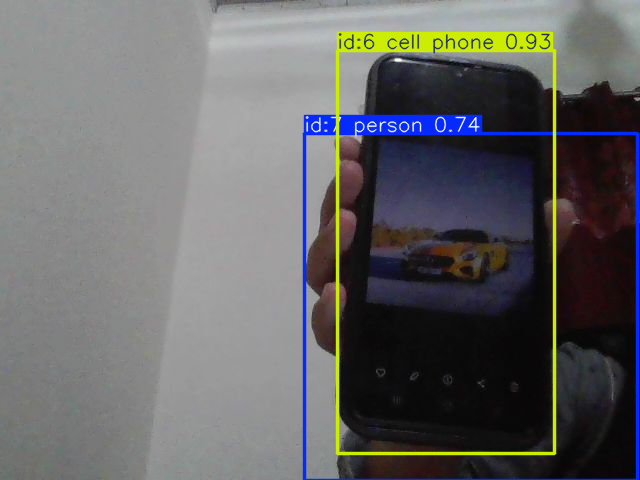

KeyboardInterrupt: 

In [ ]:
# 1. Setup & Model Load
!pip install ultralytics -q
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab.output import eval_js
from base64 import b64decode
import io
from PIL import Image
import time
from google.colab import output

model = YOLO('yolov8n.pt')

# 2. Simplified JavaScript Capture (No window function needed)
def capture_frame():
    js = '''
    async function takePhoto() {
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Canvas setup
      const canvas = document.createElement('canvas');
      canvas.width = 640;
      canvas.height = 480;
      const context = canvas.getContext('2d');
      context.drawImage(video, 0, 0, 640, 480);

      // Stop stream to save memory
      stream.getVideoTracks()[0].stop();
      video.remove();

      return canvas.toDataURL('image/jpeg', 0.8);
    }
    '''
    return eval_js(f'{js} takePhoto()')

print(" System Live! Starting Tracking...")

# 3. Main Loop
try:
    while True:
        # Capture frame directly
        img_data = capture_frame()

        # Decode image
        binary = b64decode(img_data.split(',')[1])
        img = Image.open(io.BytesIO(binary))
        frame = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

        # YOLOv8 Tracking logic
        # persist=True satisfies the tracking requirement of your internship
        results = model.track(frame, persist=True, conf=0.3, iou=0.5, verbose=False)[0]

        # Annotate
        annotated_frame = results.plot()

        # Display
        output.clear(wait=True)
        cv2_imshow(annotated_frame)

        # Keep it smooth
        time.sleep(0.01)

except Exception as e:
    print(f" Error: {e}")